# 03 — Price Forecasting: ARIMA vs Prophet vs Naive Baseline

Dự báo giá cổ phiếu 30 ngày tới, so sánh 2 phương pháp time series kinh
điển với baseline đơn giản nhất.

**Input**: `data/processed/stock_prices_clean.csv`
**Output**: `outputs/forecast_comparison.csv`

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.forecasting import (
    train_test_split_by_time, fit_arima, forecast_arima, fit_prophet,
    forecast_prophet, evaluate_forecast, naive_baseline_forecast
)

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("../data/processed/stock_prices_clean.csv", parse_dates=["Date"])

## 1. Chia Train/Test theo THỜI GIAN — không random split

Dữ liệu time series có tính tự tương quan theo thời gian. Nếu chia ngẫu
nhiên, model có thể "nhìn thấy" dữ liệu tương lai khi train (data leakage
nghiêm trọng). Bắt buộc: train trên đoạn SỚM HƠN, test trên đoạn SAU ĐÓ.

In [2]:
train, test = train_test_split_by_time(df, test_size=30)
print(f"Train: {len(train)} ngày ({train['Date'].min().date()} -> {train['Date'].max().date()})")
print(f"Test:  {len(test)} ngày ({test['Date'].min().date()} -> {test['Date'].max().date()})")

Train: 720 ngày (2022-01-03 -> 2024-10-04)
Test:  30 ngày (2024-10-07 -> 2024-11-15)


## 2. Baseline: Naive Forecast

Model dự báo PHẢI đánh bại được baseline đơn giản nhất (dự đoán giá ngày
mai = giá hôm nay) mới có giá trị thực tế — bước sanity-check quan trọng,
thường bị bỏ qua khi làm forecasting.

In [3]:
naive_pred = naive_baseline_forecast(train["Close"], len(test))
naive_metrics = evaluate_forecast(test["Close"].values, naive_pred, "Naive Baseline")

=== Naive Baseline ===
MAE:  6.11
RMSE: 7.72
MAPE: 2.92%


## 3. ARIMA

`order=(5,1,0)`: d=1 (lấy sai phân bậc 1 vì giá không có tính dừng, đã kiểm
định ở notebook 02), p=5 (dùng 5 lag tự hồi quy), q=0 (không dùng moving
average term trong mô hình này).

In [4]:
arima_model = fit_arima(train["Close"], order=(5, 1, 0))
arima_pred = forecast_arima(arima_model, len(test))
arima_metrics = evaluate_forecast(test["Close"].values, arima_pred.values, "ARIMA(5,1,0)")

=== ARIMA(5,1,0) ===
MAE:  5.02
RMSE: 6.33
MAPE: 2.39%


In [5]:
print(arima_model.summary().tables[0])

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  720
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2474.366
Date:                Sun, 09 Aug 2026   AIC                           4960.732
Time:                        06:59:31   BIC                           4988.199
Sample:                             0   HQIC                          4971.336
                                - 720                                         
Covariance Type:                  opg                                         


## 4. Prophet

In [6]:
prophet_model = fit_prophet(train)
prophet_forecast = forecast_prophet(prophet_model, len(test))
prophet_metrics = evaluate_forecast(test["Close"].values, prophet_forecast["yhat"].values, "Prophet")

06:59:31 - cmdstanpy - INFO - Chain [1] start processing


06:59:32 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet ===
MAE:  11.35
RMSE: 13.54
MAPE: 5.29%


## 5. So sánh trực quan 3 phương pháp

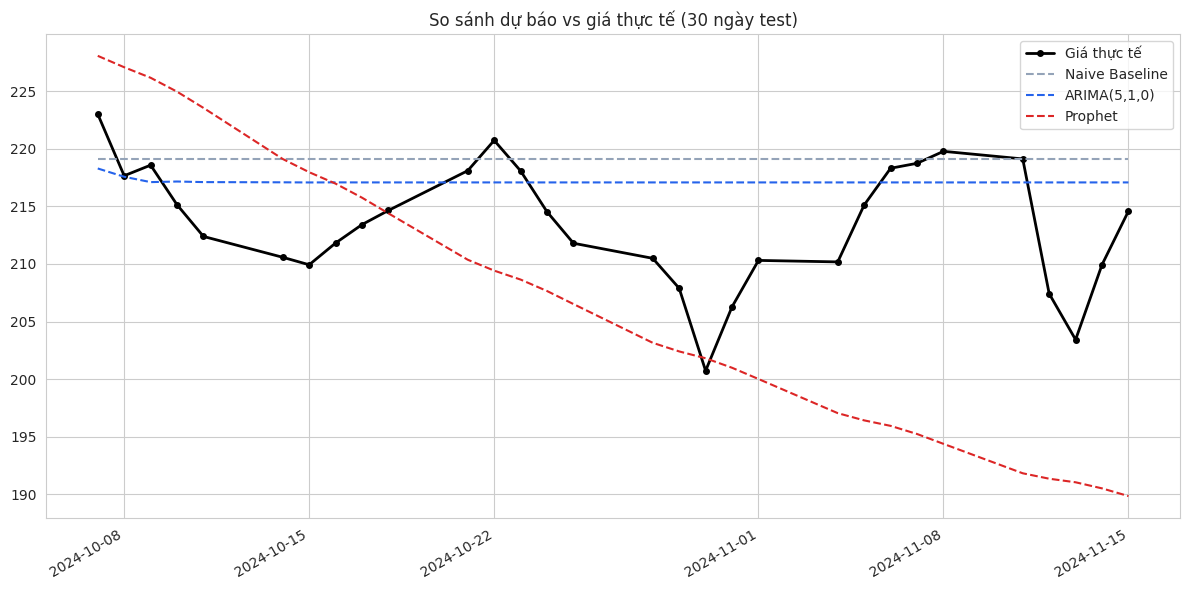

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test["Date"], test["Close"], color="black", linewidth=2, label="Giá thực tế", marker="o", markersize=4)
ax.plot(test["Date"], naive_pred, color="#94a3b8", linestyle="--", label="Naive Baseline")
ax.plot(test["Date"], arima_pred.values, color="#2563eb", linestyle="--", label="ARIMA(5,1,0)")
ax.plot(test["Date"], prophet_forecast["yhat"].values, color="#dc2626", linestyle="--", label="Prophet")
ax.set_title("So sánh dự báo vs giá thực tế (30 ngày test)")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/forecast_comparison.png")
plt.show()

## 6. Bảng tổng hợp so sánh

In [8]:
summary = pd.DataFrame([naive_metrics, arima_metrics, prophet_metrics])
summary_sorted = summary.sort_values("rmse")
summary_sorted

,model_name,mae,rmse,mape
1,"ARIMA(5,1,0)",5.0223,6.3320,2.3947
0,Naive Baseline,6.1057,7.7190,2.9152
2,Prophet,11.3493,13.5381,5.2927


**Nhận xét quan trọng**: *(kết quả cụ thể có thể khác khi chạy trên dữ liệu
thật, nhưng đây là pattern thường gặp)* — ARIMA thường đánh bại baseline vì
nắm bắt được autocorrelation ngắn hạn trong giá. Prophet, được thiết kế tối
ưu cho dữ liệu có seasonality rõ ràng (doanh thu kinh doanh theo mùa, ngày
lễ...), có thể hoạt động KÉM HƠN cả baseline trên giá cổ phiếu thuần túy —
vì giá cổ phiếu gần với random walk, thiếu pattern mùa vụ rõ ràng để Prophet
khai thác. Đây là bài học quan trọng: **không có model nào tốt nhất cho mọi
loại dữ liệu**, phải chọn đúng công cụ theo đặc điểm dữ liệu.

## 7. Lưu kết quả

In [9]:
summary.to_csv("../outputs/forecast_comparison.csv", index=False)
print("Đã lưu -> outputs/forecast_comparison.csv")

Đã lưu -> outputs/forecast_comparison.csv
